<a href="https://colab.research.google.com/github/melaniee-sudo/machine-learning-udg-tareas/blob/main/p6_random_forest_wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#base de datos Wine
wine = load_wine()

#variables de entrada
X = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

#variable que se desea predecir
y = pd.Series(
    wine.target,
    name="clase"
)

#dividir los datos: 70 % para entrenamiento y 30 % para prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

#cuantos arboles que se van a probar
cantidades_arboles = [10, 50, 100]

#listas para guardar los resultados
resultados = []
importancias_modelos = {}

#entrenar un Random Forest para cada cantidad de árboles
for cantidad in cantidades_arboles:

    modelo = RandomForestClassifier(
        n_estimators=cantidad,
        random_state=42
    )


    modelo.fit(X_train, y_train)#entrenamiento
    predicciones = modelo.predict(X_test)#predicciones con los datos de prueba

    #calcular Accuracy
    accuracy = accuracy_score(
        y_test,
        predicciones
    )

    #guardar las importancias de las características
    importancias = pd.Series(
        modelo.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    importancias_modelos[cantidad] = importancias

    # Guardar los resultados
    resultados.append({
        "Cantidad de árboles": cantidad,
        "Accuracy": accuracy,
        "Accuracy (%)": accuracy * 100
    })

# Mostrar tabla de resultados
tabla_resultados = pd.DataFrame(resultados)

print("Resultados de los modelos:")
display(tabla_resultados)

#mostrar las caracteristicas mas importantes de cada modelo
for cantidad in cantidades_arboles:

    print("\nModelo con", cantidad, "árboles")
    print(importancias_modelos[cantidad].head(5))

Resultados de los modelos:


,Cantidad de árboles,Accuracy,Accuracy (%)
0,10,0.962963,96.296296
1,50,1.000000,100.000000
2,100,1.000000,100.000000



Modelo con 10 árboles
flavanoids         0.270484
hue                0.144049
alcohol            0.139047
magnesium          0.105825
color_intensity    0.095215
dtype: float64

Modelo con 50 árboles
flavanoids                      0.177677
alcohol                         0.155654
color_intensity                 0.134549
hue                             0.133527
od280/od315_of_diluted_wines    0.103641
dtype: float64

Modelo con 100 árboles
alcohol            0.162715
color_intensity    0.159719
flavanoids         0.156283
proline            0.124081
hue                0.111019
dtype: float64


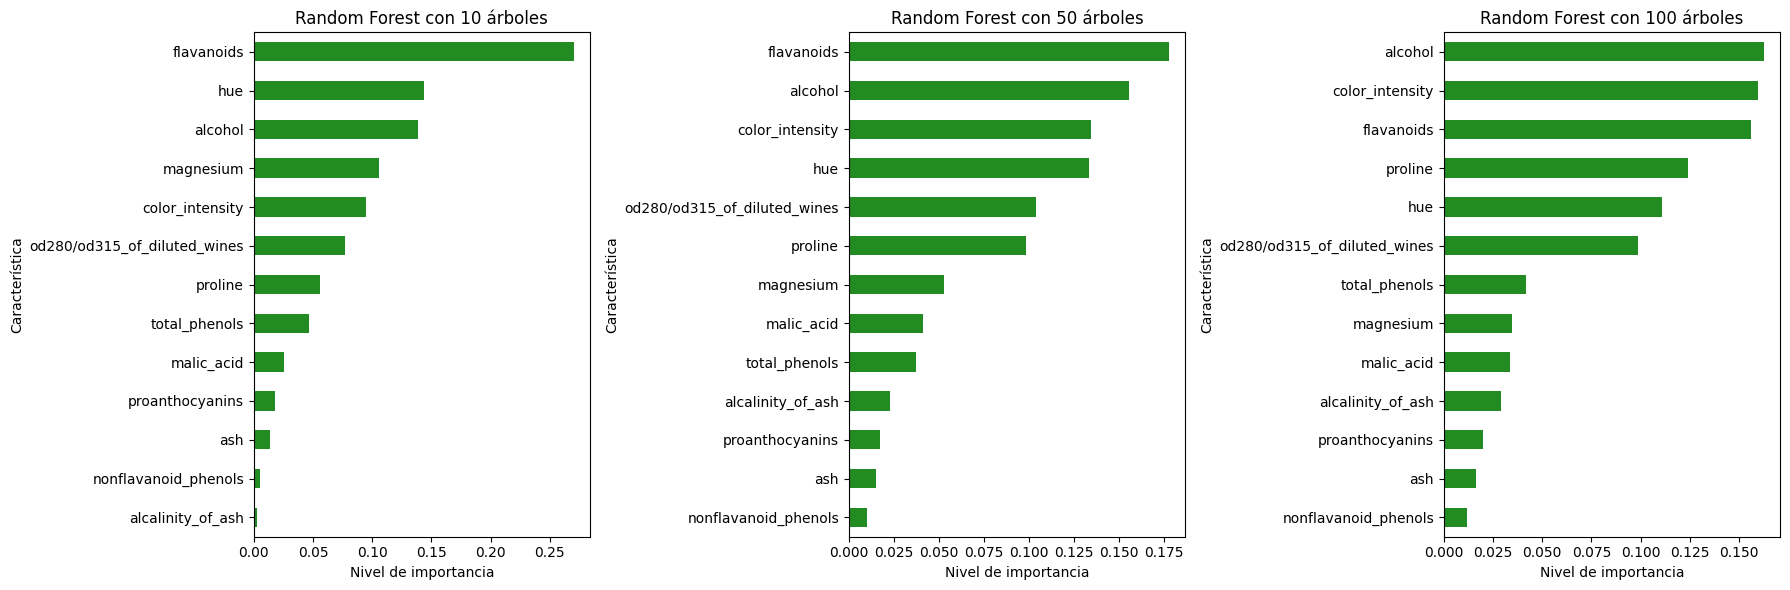

In [4]:
#grafica de importancia para cada modelo
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

for posicion, cantidad in enumerate(cantidades_arboles):

    importancias_modelos[cantidad].sort_values().plot(
        kind="barh",
        ax=axes[posicion],
        color="forestgreen"
    )

    axes[posicion].set_title(
        "Random Forest con "
        + str(cantidad)
        + " árboles"
    )

    axes[posicion].set_xlabel(
        "Nivel de importancia"
    )

    axes[posicion].set_ylabel(
        "Característica"
    )

plt.tight_layout()
plt.show()

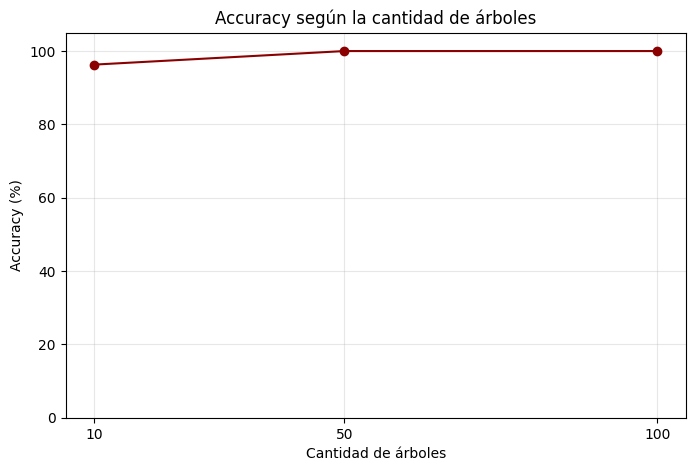

In [6]:
#comparativa del Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    tabla_resultados["Cantidad de árboles"],
    tabla_resultados["Accuracy (%)"],
    marker="o",
    color="darkred"
)

plt.title("Accuracy según la cantidad de árboles")
plt.xlabel("Cantidad de árboles")
plt.ylabel("Accuracy (%)")
plt.xticks(cantidades_arboles)
plt.ylim(0, 105)
plt.grid(alpha=0.3)

plt.show()